In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Chronic_Kidney_Dsease_data.csv")


print("Shape:", df.shape)
print(df.head())

Shape: (1659, 54)
   PatientID  Age  Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0          1   71       0          0                    0               2   
1          2   34       0          0                    1               3   
2          3   80       1          1                    0               1   
3          4   40       0          2                    0               1   
4          5   43       0          1                    1               2   

         BMI  Smoking  AlcoholConsumption  PhysicalActivity  ...   Itching  \
0  31.069414        1            5.128112          1.676220  ...  7.556302   
1  29.692119        1           18.609552          8.377574  ...  6.836766   
2  37.394822        1           11.882429          9.607401  ...  2.144722   
3  31.329680        0           16.020165          0.408871  ...  7.077188   
4  23.726311        0            7.944146          0.780319  ...  3.553118   

   QualityOfLifeScore  HeavyMetalsExposure  Occupa

In [3]:
df.columns = (
    df.columns.str.strip()
             .str.replace(" ", "_")
             .str.replace("-", "_")
)
df = df.drop_duplicates()


In [4]:
df.drop(columns=["PatientID", "DoctorInCharge"], inplace=True, errors="ignore")

In [5]:
target_col = "Diagnosis"   # CKD label (0/1)
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

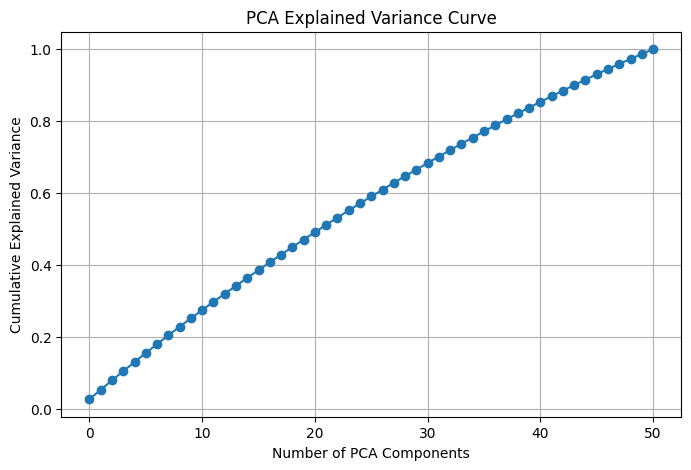

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker="o")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()


In [10]:


pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original feature count:", X_train.shape[1])
print("Reduced feature count after PCA:", X_train_pca.shape[1])

Original feature count: 51
Reduced feature count after PCA: 48


In [11]:
# Drop non-numeric columns if any
df_numeric = df.select_dtypes(include=[np.number])

# Calculate variance for each feature
feature_variance = df_numeric.var()

# Convert to dataframe for better viewing
variance_df = pd.DataFrame({
    "Feature": feature_variance.index,
    "Variance": feature_variance.values
}).sort_values(by="Variance", ascending=False)

print(variance_df)

                          Feature      Variance
33       CholesterolTriglycerides  10064.455011
24                            ACR   7542.972372
30               CholesterolTotal   1906.770777
31                 CholesterolLDL   1818.597843
18              FastingBloodSugar   1336.855508
22                            GFR    903.052717
44             QualityOfLifeScore    774.374914
16                     SystolicBP    663.979219
32                 CholesterolHDL    536.868117
0                             Age    422.292533
17                    DiastolicBP    301.177931
21                      BUNLevels    164.046449
5                             BMI     53.124714
7              AlcoholConsumption     33.625926
25        SerumElectrolytesSodium      8.442485
50                 HealthLiteracy      8.416603
40                  FatigueLevels      8.388617
43                        Itching      8.297052
49            MedicationAdherence      8.236665
36                      NSAIDsUse      8

In [13]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [15]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix


# 3) Clean text + force Gender categorical
for c in X.select_dtypes(include=["object"]).columns:
    X[c] = X[c].astype(str).str.strip()

if "Gender" in X.columns:
    X["Gender"] = X["Gender"].astype("category")

# 4) DEFINE THESE (this is what your error is about)
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Has Gender?", "Gender" in cat_cols)

# 5) Preprocess
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# 6) Model
model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# 7) Split + Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

# 8) Evaluate
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Numeric cols: 50
Categorical cols: 1
Has Gender? True
Accuracy: 0.927710843373494
ROC-AUC: 0.783485124468731
Confusion Matrix:
 [[  4  23]
 [  1 304]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.15      0.25        27
           1       0.93      1.00      0.96       305

    accuracy                           0.93       332
   macro avg       0.86      0.57      0.61       332
weighted avg       0.92      0.93      0.90       332



In [16]:

import pandas as pd

# clean object columns
for c in X.select_dtypes(include=["object"]).columns:
    X[c] = X[c].astype(str).str.strip()

# Force Gender to categorical (so it won't go into numeric median imputer)
if "Gender" in X.columns:
    X["Gender"] = X["Gender"].astype("category")

# Recompute column lists correctly
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# (optional safety) ensure no overlap
num_cols = [c for c in num_cols if c not in cat_cols]
cat_cols = [c for c in cat_cols if c not in num_cols]

In [17]:
# Clean text
for c in X.select_dtypes(include=["object"]).columns:
    X[c] = X[c].astype(str).str.strip()

# Ensure Gender is categorical
if "Gender" in X.columns:
    X["Gender"] = X["Gender"].astype("category")

# Column types
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

/opt/anaconda3/envs/mediapipe-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


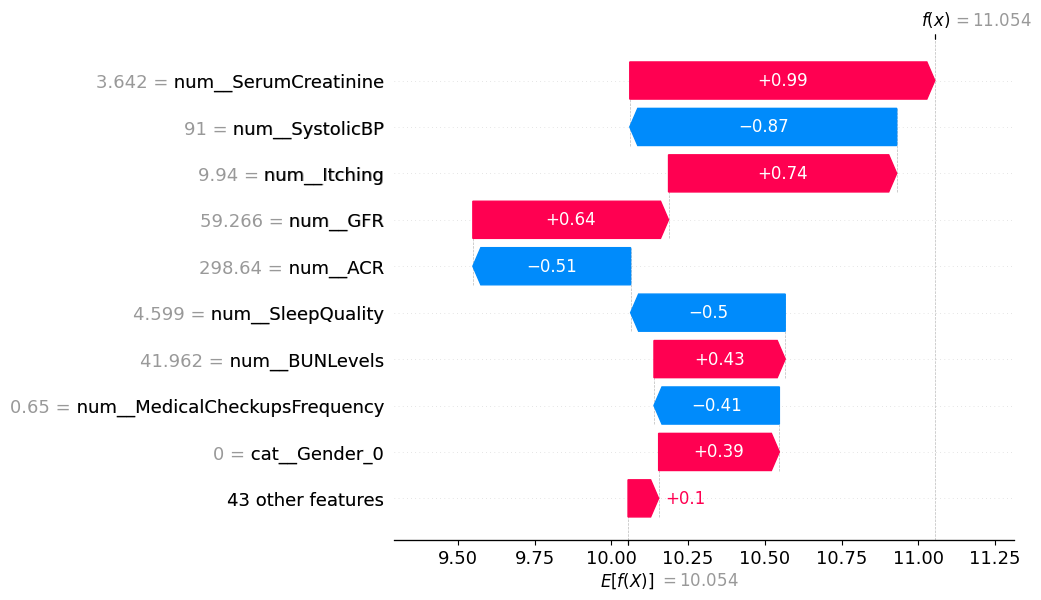

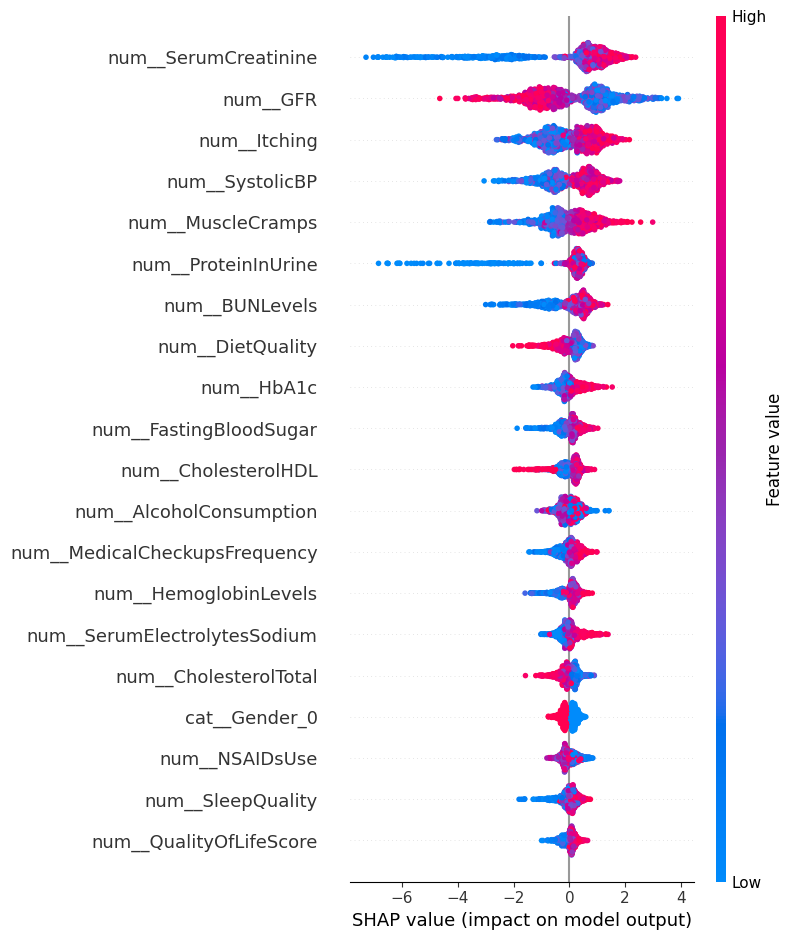

In [18]:


import shap


# 1) Get processed training data
X_train_processed = clf.named_steps["preprocess"].transform(X_train)
feature_names = clf.named_steps["preprocess"].get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

# 2) Get trained model
model = clf.named_steps["model"]

# 3) Create TreeExplainer explicitly and disable additivity check
explainer = shap.TreeExplainer(model)

# 4) Explain ONE test sample
X_test_processed = clf.named_steps["preprocess"].transform(X_test.iloc[[0]])
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

shap_values = explainer.shap_values(
    X_test_processed_df,
    check_additivity=False
)

# Waterfall plot (local explanation)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_processed_df.iloc[0],
        feature_names=feature_names
    )
)

# 5) Global explanation (on full training set)
shap_values_full = explainer.shap_values(
    X_train_processed_df,
    check_additivity=False
)

shap.summary_plot(
    shap_values_full,
    X_train_processed_df,
    feature_names=feature_names
)

In [ ]:


import joblib
import pandas as pd

# required columns
required_cols = X.columns.tolist()

# defaults: median for numeric, mode for categorical/object
defaults = {}
for c in required_cols:
    if pd.api.types.is_numeric_dtype(X[c]):
        defaults[c] = float(X[c].median())
    else:
        defaults[c] = X[c].mode(dropna=True).iloc[0]

joblib.dump(clf, "ckd_model.pkl")
joblib.dump(X_train, "X_train_background.pkl")
joblib.dump({"required_cols": required_cols, "defaults": defaults}, "ckd_schema.pkl")

['ckd_schema.pkl']